# **Import Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [2]:
# Batas omzet tahunan PP 7/2021 dikonversi menjadi batas bulanan.
# Label: UMI=mikro, UKE=kecil, UME=menengah, UBE=besar.
SCALE_BOUNDS_MONTHLY = {
    'UMI': (0, 2_000_000_000 / 12),
    'UKE': (2_000_000_000 / 12, 15_000_000_000 / 12),
    'UME': (15_000_000_000 / 12, 50_000_000_000 / 12),
    'UBE': (50_000_000_000 / 12, np.inf),
}
SCALE_ORDER = ['UMI', 'UKE', 'UME', 'UBE']

In [3]:
# define project root path
PROJECT_ROOT = Path().resolve().parent

# **Load Data**

### **Data Dictionary — `merchants.csv`**

Tabel utama yang menyimpan identitas, segmentasi bisnis, status acquiring BNI, dan ukuran komersial setiap merchant. Satu baris merepresentasikan satu merchant.

| Kolom | Makna dalam konteks proyek |
|---|---|
| `merchant_id` | Primary key synthetic merchant dengan format `Mxxxx`; dipakai untuk menghubungkan tabel merchant, profil, transaksi, dan output model. |
| `nama` | Nama usaha/merchant untuk kebutuhan identifikasi dan tampilan dashboard. |
| `kategori` | Kelompok industri utama merchant, misalnya F&B, Grocery, Fashion, Electronics, atau Automotive. |
| `sub_kategori` | Jenis usaha yang lebih spesifik di bawah `kategori`, misalnya cafe atau restaurant. |
| `tipe` | Peran merchant dalam ekosistem usaha: `retailer` atau `supplier`. |
| `kota` | Kota lokasi operasional merchant; digunakan untuk analisis geografis dan filter dashboard. |
| `kecamatan` | Area lokasi yang lebih granular di dalam kota. |
| `is_bni_acquiring` | Menandai apakah merchant sudah menggunakan layanan **merchant acquiring BNI** (`Ya`/`Tidak`). Kolom ini bukan penanda kepemilikan rekening BNI secara umum. Merchant `Tidak` menjadi populasi target akuisisi. |
| `produk_bni` | Produk acquiring yang saat ini digunakan merchant existing BNI: `QRIS` atau `QRIS + EDC`. Bernilai kosong untuk merchant yang belum di-acquire. |
| `tgl_registrasi` | Tanggal merchant mulai terdaftar pada layanan acquiring BNI; secara natural kosong untuk target non-BNI. |
| `status` | Status hubungan acquiring merchant, misalnya aktif atau tidak aktif; dapat kosong jika merchant belum menjadi merchant BNI. |
| `skala_usaha` | Klasifikasi skala berdasarkan omzet: UMI (mikro), UKE (kecil), UME (menengah), dan UBE (besar), mengacu pada batas hasil penjualan PP 7/2021 yang dikonversi ke bulanan. |
| `avg_omzet_bulanan` | Estimasi rata-rata total omzet merchant per bulan. Nilai ini menggambarkan kapasitas bisnis dan tidak harus sama dengan total transaksi pada dataset, karena transaksi merupakan sampel aktivitas. |

**Relasi utama:** `merchant_id` bersifat unik dan menjadi key satu-ke-satu dengan `merchant_profiles.csv`, serta key tujuan transaksi pada `transactions_raw.csv`.

### **Data Dictionary — `transactions_raw.csv`**

Tabel event transaksi synthetic yang memuat aktivitas Customer-to-Merchant (C2M) dan Merchant-to-Merchant (M2M). Tabel raw sengaja mengandung sebagian nilai kosong, duplikat reference number, refund, dan test transaction agar proses data cleaning tetap realistis.

| Kolom | Makna dalam konteks proyek |
|---|---|
| `trx_id` | Identifier unik setiap baris transaksi synthetic. |
| `timestamp` | Waktu terjadinya transaksi; digunakan untuk analisis tren bulanan dan pola waktu. |
| `source_id` | Pihak pengirim/pembayar. Prefix `C` menunjukkan customer dan prefix `M` menunjukkan merchant. Kombinasi prefix ini digunakan untuk membedakan C2M dan M2M. |
| `target_id` | Merchant penerima transaksi, direferensikan ke `merchant_id` pada tabel merchant. |
| `amount` | Nilai transaksi dalam rupiah. Pada raw data dapat berisi nilai kosong, nol untuk test transaction, atau negatif untuk refund; hanya nilai positif dan valid yang digunakan setelah cleaning. |
| `channel` | Kanal transaksi: `QRIS`, `EDC`, atau `transfer`. Nilai kosong diperlakukan sebagai masalah kualitas data. |
| `payment_type` | Instrumen pembayaran: `QRIS`, `debit`, `credit_card`, atau `bank_transfer`. Seluruh `debit` pada data synthetic diasumsikan sebagai kartu debit BNI pada EDC BNI, sehingga MDR debit menggunakan tarif flat 0,15%. |
| `status` | Status pemrosesan transaksi: `success`, `failed`, atau `pending`. Analisis downstream hanya menggunakan transaksi sukses. |
| `description` | Deskripsi singkat konteks transaksi, termasuk tipe pembayaran/kategori, refund, atau test transaction. |
| `ref_number` | Nomor referensi transaksi. Duplikasi dapat muncul pada raw data dan ditangani pada tahap cleaning. |

**Interpretasi tipe transaksi:** `source_id` customer → `target_id` merchant adalah C2M; `source_id` merchant → `target_id` merchant adalah M2M. Klasifikasi `trx_type` baru ditambahkan saat proses cleaning dan bukan kolom raw.

**Kalibrasi synthetic `amount`:** nominal transaksi positif C2M dibuat berbeda menurut `skala_usaha` (UMI < UKE < UME < UBE) dengan distribusi log-normal dan variasi antar-instrumen. Hanya `amount` yang dikalibrasi; pasangan customer–merchant, jumlah baris, timestamp, status, dan payment type tidak diubah agar topology affinity graph tetap sama.


### **Data Dictionary — `merchant_profiles.csv`**

Tabel profil operasional dan digital merchant. Informasi ini melengkapi karakteristik komersial pada `merchants.csv` dan digunakan sebagai fitur pendukung analisis serta product recommendation.

| Kolom | Makna dalam konteks proyek |
|---|---|
| `merchant_id` | Foreign key menuju merchant; satu merchant memiliki paling banyak satu profil. |
| `lama_beroperasi_tahun` | Lama usaha beroperasi dalam tahun, sebagai indikator kematangan bisnis. |
| `jumlah_karyawan` | Estimasi jumlah tenaga kerja merchant, sebagai salah satu indikator kapasitas operasional. |
| `rating_google` | Rating publik merchant pada Google. Nilai kosong berarti rating tidak tersedia, bukan otomatis berkualitas buruk. Pada cleaning dibuat indikator `has_rating` untuk membedakan kondisi tersebut. |
| `jumlah_outlet` | Jumlah cabang/outlet yang dimiliki merchant. |
| `has_website` | Ketersediaan website resmi (`Ya`/`Tidak`), sebagai indikator digital presence. |
| `has_social_media` | Ketersediaan akun media sosial usaha (`Ya`/`Tidak`), sebagai indikator aktivitas digital. |

**Relasi utama:** tabel ini digabungkan ke data merchant menggunakan `merchant_id` dengan relasi satu-ke-satu.

In [4]:
# load all data
merchant_profile = pd.read_csv(f'{PROJECT_ROOT}/data/raw/merchant_profiles.csv')
merchants = pd.read_csv(f'{PROJECT_ROOT}/data/raw/merchants.csv')
trx_raw = pd.read_csv(f'{PROJECT_ROOT}/data/raw/transactions_raw.csv')

In [5]:
# quick look at each df
print('Merchant Dataframe:')
print(merchants.info())
display(merchants.head())

Merchant Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   merchant_id        708 non-null    str    
 1   nama               708 non-null    str    
 2   kategori           708 non-null    str    
 3   sub_kategori       708 non-null    str    
 4   tipe               708 non-null    str    
 5   kota               708 non-null    str    
 6   kecamatan          673 non-null    str    
 7   is_bni_acquiring   708 non-null    str    
 8   produk_bni         462 non-null    str    
 9   tgl_registrasi     462 non-null    str    
 10  status             462 non-null    str    
 11  skala_usaha        708 non-null    str    
 12  avg_omzet_bulanan  687 non-null    float64
dtypes: float64(1), str(12)
memory usage: 72.0 KB
None


,merchant_id,nama,kategori,sub_kategori,tipe,kota,kecamatan,is_bni_acquiring,produk_bni,tgl_registrasi,status,skala_usaha,avg_omzet_bulanan
0,M0001,PT Berseri Boga Sejahtera,F&B,cafe,retailer,Jakarta,Kemang,Tidak,NaN,NaN,NaN,UME,2.561833e+09
1,M0002,Pusaka Sajian Distribusi,F&B,restaurant,supplier,Jakarta,Pluit,Tidak,NaN,NaN,NaN,UME,2.791232e+09
2,M0003,Agen Bahan Kue Mbak Rani,F&B,restaurant,supplier,Tangerang,Alam Sutera,Ya,QRIS,2022-04-22,aktif,UMI,6.379642e+07
3,M0004,Sinar Kuliner Center,F&B,cafe,retailer,Depok,Cimanggis,Tidak,NaN,NaN,NaN,UKE,3.581056e+08
4,M0005,Kafe Berkah Utama,F&B,catering,retailer,Bekasi,Harapan Indah,Ya,QRIS,2023-10-09,aktif,UMI,1.135023e+08


In [6]:
print("Raw Transactions Dataframe:")
print(trx_raw.info())
display(trx_raw.head())

Raw Transactions Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 71400 entries, 0 to 71399
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trx_id        71400 non-null  str    
 1   timestamp     71400 non-null  str    
 2   source_id     71400 non-null  str    
 3   target_id     71400 non-null  str    
 4   amount        70710 non-null  float64
 5   channel       70690 non-null  str    
 6   payment_type  70690 non-null  str    
 7   status        71400 non-null  str    
 8   description   71400 non-null  str    
 9   ref_number    71400 non-null  str    
dtypes: float64(1), str(9)
memory usage: 5.4 MB
None


,trx_id,timestamp,source_id,target_id,amount,channel,payment_type,status,description,ref_number
0,T000000,2026-03-21 16:37:58,C00675,M0607,31707560.28,EDC,debit,success,C2M payment - Automotive,REF76360417
1,T000001,2026-02-13 23:16:16,C00075,M0411,128355.21,QRIS,QRIS,success,C2M payment - Grocery,REF87061588
2,T000002,2025-09-05 20:03:14,C01585,M0027,25281340.74,transfer,bank_transfer,success,C2M payment - F&B,REF18154156
3,T000003,2025-12-01 04:29:20,C01081,M0467,17007513.94,QRIS,QRIS,success,C2M payment - Grocery,REF42510488
4,T000004,2025-11-11 23:57:17,C00993,M0381,3888807.26,transfer,bank_transfer,success,C2M payment - Grocery,REF63695970


In [7]:
print("Merchant Profiles Dataframe:")
print(merchant_profile.info())
print("\n", merchant_profile.head(3))

Merchant Profiles Dataframe:
<class 'pandas.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   merchant_id            708 non-null    str    
 1   lama_beroperasi_tahun  645 non-null    float64
 2   jumlah_karyawan        631 non-null    float64
 3   rating_google          531 non-null    float64
 4   jumlah_outlet          671 non-null    float64
 5   has_website            579 non-null    str    
 6   has_social_media       567 non-null    str    
dtypes: float64(4), str(3)
memory usage: 38.8 KB
None

   merchant_id  lama_beroperasi_tahun  jumlah_karyawan  rating_google  \
0       M0001                    1.0             12.0            3.7   
1       M0002                   19.0             28.0            3.7   
2       M0003                   20.0             13.0            3.9   

   jumlah_outlet has_website has_social_media  
0            3.0 

# **Data Quality Assessment**

## **2.1 Missing Values Summary**

In [8]:
def missing_summary(df, table_name):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': pct
    })
    summary = summary[summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)

    print(f'Checking Missing Values on Table => {table_name}')
    if len(summary) == 0:
        print('There is no missing values.')
        print()
    else:
        print(summary)
        print()

    return summary

In [9]:
# check missing summary on each dataframe
missing_merchants = missing_summary(merchants, "merchants")
missing_trx = missing_summary(trx_raw, "transactions_raw")
missing_profile = missing_summary(merchant_profile, "merchant_profiles")

Checking Missing Values on Table => merchants
                   missing_count  missing_pct
produk_bni                   246        34.75
status                       246        34.75
tgl_registrasi               246        34.75
kecamatan                     35         4.94
avg_omzet_bulanan             21         2.97

Checking Missing Values on Table => transactions_raw
              missing_count  missing_pct
channel                 710         0.99
payment_type            710         0.99
amount                  690         0.97

Checking Missing Values on Table => merchant_profiles
                       missing_count  missing_pct
rating_google                    177        25.00
has_social_media                 141        19.92
has_website                      129        18.22
jumlah_karyawan                   77        10.88
lama_beroperasi_tahun             63         8.90
jumlah_outlet                     37         5.23



## **2.2 Duplicate Detection**

In [10]:
# normalized merchants name
merchants['nama_normalized'] = (
    merchants['nama']
    .fillna('')
    .str.lower()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True) # delete double spaces
)

# find the names appear more than once after normalizing process
nama_duplicates = merchants[
    merchants['nama_normalized'].duplicated(keep=False) &
    (merchants['nama_normalized'] != '')
].sort_values('nama_normalized')

print(f"Total rows with similar names: {len(nama_duplicates)}")
if len(nama_duplicates) > 0:
    print(nama_duplicates[['merchant_id', 'nama', 'nama_normalized', 'kategori', 'kota', 'is_bni_acquiring']].to_string())

Total rows with similar names: 0


In [11]:
# check duplicates ref_number on transactions table
ref_dupes = trx_raw[trx_raw.duplicated(subset='ref_number', keep=False)].sort_values('ref_number')
print(f"Total rows of dupliacted ref_number: {len(ref_dupes)}")
print(f"Total unique ref_number got duplicated: {ref_dupes['ref_number'].nunique()}")
print(f"\nContoh duplikat (5 pertama):")
print(ref_dupes.head(5)[['trx_id', 'ref_number', 'source_id', 'target_id', 'amount', 'status']])

Total rows of dupliacted ref_number: 408
Total unique ref_number got duplicated: 204

Contoh duplikat (5 pertama):
        trx_id   ref_number source_id target_id       amount   status
53015  T053015  REF00067371    C01667     M0469  10969333.32  success
4960   T004960  REF00067371    C00918     M0451  12424112.28  success
27331  T027331  REF00936842    C00041     M0580  26250616.55  success
27330  T027330  REF00936842     M0431     M0379  24239908.64  success
33944  T033944  REF01126117    C01640     M0643   9361793.84  success


# **2.3 Detect Anomalies**

In [12]:
# check amount anomalies on transaction data
print('Amount analysis (before cleaning):')
print(f"\nNULL amount:     {trx_raw['amount'].isna().sum()}")
print(f"Negative amount: {(trx_raw['amount'] < 0).sum()}")
print(f"Zero amount:     {(trx_raw['amount'] == 0).sum()}")

display(trx_raw['amount'].describe())

Amount analysis (before cleaning):

NULL amount:     690
Negative amount: 420
Zero amount:     210


count    7.071000e+04
mean     1.600030e+07
std      1.910500e+07
min     -7.500000e+07
25%      3.388953e+06
50%      1.001619e+07
75%      2.122524e+07
max      2.000000e+08
Name: amount, dtype: float64

In [13]:
# check negative amount distribution => should be refund
refunds = trx_raw[trx_raw['amount'] < 0]
print('Refund Transactions:')
print(f'\nRefunds total: {len(refunds)}')
print(f"Check refunds unique description: {list(refunds['description'].unique())}")

Refund Transactions:

Refunds total: 420
Check refunds unique description: ['Refund transaction']


In [14]:
# check transaction amount = 0 => should be test transactions
test_trx = trx_raw[trx_raw['amount'] == 0]
print(f"Test transactions (amount=0):")
print(f"\nJumlah: {len(test_trx)}")
print(f"Check test transaction unique description: {list(test_trx['description'].unique())}")

Test transactions (amount=0):

Jumlah: 210
Check test transaction unique description: ['Test transaction']


In [15]:
# outlier detection on amount

# filter only on positive amount and success transaction
valid_amounts = trx_raw[(trx_raw['amount'] > 0) & (trx_raw['status'] == 'success')]['amount']

# define outliers boundaries
Q1 = valid_amounts.quantile(0.25)
Q3 = valid_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # 3 times IQR for less-aggresive outlier detection

# generate the information of outlier findings
outliers = valid_amounts[valid_amounts > upper_bound]
print(f"Outlier Detection (IQR method, 3x):")
print(f"\nQ1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"Upper bound: {upper_bound:,.0f}")
print(f"Total outliers: {len(outliers)} ({len(outliers)/len(valid_amounts)*100:.2f}%) of {len(valid_amounts)} data")
print(f"Range outliers: {outliers.min():,.0f} — {outliers.max():,.0f}")

Outlier Detection (IQR method, 3x):

Q1: 3,618,282 | Q3: 21,367,111 | IQR: 17,748,830
Upper bound: 74,613,601
Total outliers: 2354 (3.57%) of 65864 data
Range outliers: 74,614,213 — 200,000,000


In [16]:
# check status distribution
print('Transaction Status Distribution:\n')
print(trx_raw['status'].value_counts(normalize=True).round(4) * 100)

Transaction Status Distribution:

status
success    93.99
failed      3.78
pending     2.22
Name: proportion, dtype: float64


In [17]:
# check channel distribution
print('Transaction Channel Distribution:\n')
print(trx_raw['channel'].value_counts(normalize=True).round(4) * 100)

Transaction Channel Distribution:

channel
QRIS        35.95
transfer    32.09
EDC         31.96
Name: proportion, dtype: float64


In [18]:
# check transaction type => Merchants to Merchants and Customers to Merchants
trx_raw['trx_type'] = np.where(
    trx_raw['source_id'].str.startswith('M'), 
    'M2M (Merchant-to-Merchant)', 
    'C2M (Customer-to-Merchant)'
)

print('Transaction type:')
print()
print(trx_raw['trx_type'].value_counts(normalize=True).round(4) * 100)

Transaction type:

trx_type
C2M (Customer-to-Merchant)    74.7
M2M (Merchant-to-Merchant)    25.3
Name: proportion, dtype: float64


In [19]:
# check potential anomaly transaction time

# convert timestamp data type into datetime
print('Initial type data of timestamp:', trx_raw['timestamp'].dtype)
print('Changing timestamp type data into datetime. . . .')
trx_raw['timestamp_dt'] = pd.to_datetime(trx_raw['timestamp'])
print('Type data of timestamp after casting:', trx_raw['timestamp_dt'].dtype)
trx_raw['hour'] = trx_raw['timestamp_dt'].dt.hour

# check odd hours of transaction time
odd_hours = trx_raw[trx_raw['hour'].between(1, 4)]
print(f'\nTotal of odd hour transactions (01-00:04:59): {len(odd_hours)} transactions')


Initial type data of timestamp: str
Changing timestamp type data into datetime. . . .
Type data of timestamp after casting: datetime64[us]

Total of odd hour transactions (01-00:04:59): 11909 transactions


# **3. Data Cleaning**

We have already finished on checking the data quality. Now we can take some actions to clean the data based on our prior observation. 

## **3.1 Clean Merchants**

In [20]:
# drop near-duplicate merchants name => keep the most completed data

# completeness => calculate non-null columns
merchants_clean = merchants.copy()
merchants_clean['completeness'] = merchants_clean.drop(columns=['nama_normalized']).notna().sum(axis=1)

# Sort by completeness descending, then drop duplicated nama_normalized + kota
# (merchant dengan nama sama di kota berbeda adalah entitas berbeda, bukan duplikat)
merchants_clean = (
    merchants_clean
    .sort_values('completeness', ascending=False)
    .drop_duplicates(subset=['nama_normalized', 'kota'], keep='first')
    .drop(columns=['completeness', 'nama_normalized'])
    .reset_index(drop=True)
)

print(f'Merchants before dropping duplicated: {len(merchants)}')
print(f"Merchants after dropping duplicated (nama+kota): {len(merchants_clean)}")
print("Catatan: merchant dengan nama sama di kota berbeda dipertahankan sebagai entitas terpisah")

Merchants before dropping duplicated: 708
Merchants after dropping duplicated (nama+kota): 708
Catatan: merchant dengan nama sama di kota berbeda dipertahankan sebagai entitas terpisah


In [21]:
# fill missing values on categorical columns

# fill null on nama column with 'unknown_<merchant_id>'
merchants_clean['nama'] = merchants_clean.apply(lambda row: f"Unknown_{row['merchant_id']}" if pd.isna(row['nama']) else row['nama'],axis=1)

# fill null kecamatan with 'Unknown'
merchants_clean['kecamatan'] = merchants_clean['kecamatan'].fillna('Unknown')

merchants_clean.isna().sum()

merchant_id            0
nama                   0
kategori               0
sub_kategori           0
tipe                   0
kota                   0
kecamatan              0
is_bni_acquiring       0
produk_bni           246
tgl_registrasi       246
status               246
skala_usaha            0
avg_omzet_bulanan     21
dtype: int64

Average omzet bulanan skewness: 2.4651993571446864


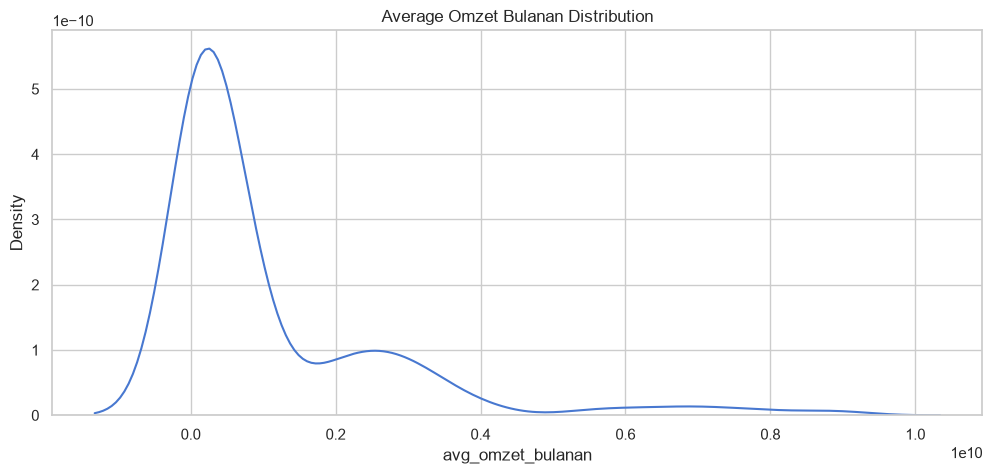

In [22]:
# check skewness avg_omzet_bulanan
print('Average omzet bulanan skewness:', merchants_clean['avg_omzet_bulanan'].skew())
sns.kdeplot(data=merchants_clean, x='avg_omzet_bulanan')
plt.title('Average Omzet Bulanan Distribution')
plt.show()

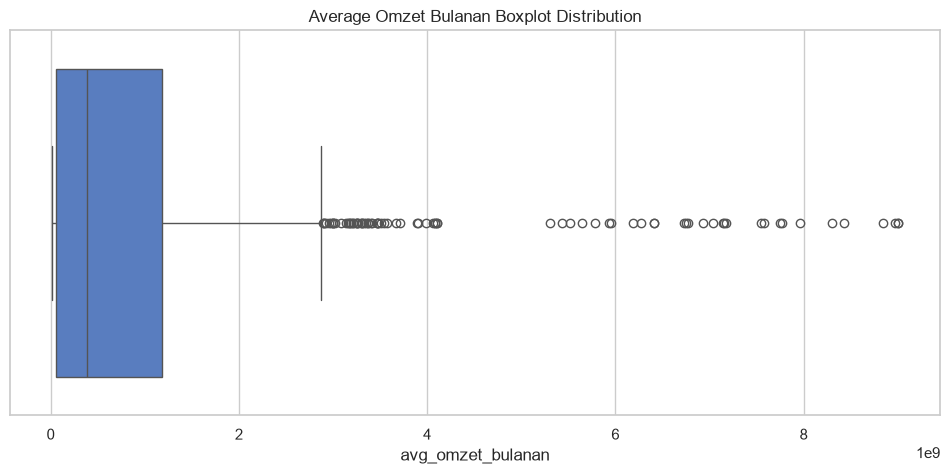

In [23]:
sns.boxplot(data=merchants_clean, x='avg_omzet_bulanan')
plt.title('Average Omzet Bulanan Boxplot Distribution')
plt.show()

Average omzet bulanan seems skewed-right distribution, yet the boxplot distribution also shows many data points outside of Q3 boundary. The most suitable way to impute missing values considering those condition is using median which robust to the outliers data.

In [24]:
# Validate scale labels, then impute turnover within comparable businesses.
invalid_scale = ~merchants_clean['skala_usaha'].isin(SCALE_ORDER)
if invalid_scale.any():
    bad_values = merchants_clean.loc[invalid_scale, 'skala_usaha'].unique().tolist()
    raise ValueError(f'Invalid skala_usaha: {bad_values}')

group_cols = ['skala_usaha', 'kategori', 'tipe']
group_median = merchants_clean.groupby(group_cols)['avg_omzet_bulanan'].transform('median')
scale_median = merchants_clean.groupby('skala_usaha')['avg_omzet_bulanan'].transform('median')
merchants_clean['avg_omzet_bulanan'] = (
    merchants_clean['avg_omzet_bulanan']
    .fillna(group_median)
    .fillna(scale_median)
)

# Turnover must remain inside the declared PP 7/2021 scale band.
scale_consistent = pd.Series(True, index=merchants_clean.index)
for scale, (lower, upper) in SCALE_BOUNDS_MONTHLY.items():
    mask = merchants_clean['skala_usaha'].eq(scale)
    if scale == 'UMI':
        scale_consistent.loc[mask] = merchants_clean.loc[mask, 'avg_omzet_bulanan'].le(upper)
    else:
        scale_consistent.loc[mask] = (
            merchants_clean.loc[mask, 'avg_omzet_bulanan'].gt(lower)
            & merchants_clean.loc[mask, 'avg_omzet_bulanan'].le(upper)
        )

if not scale_consistent.all():
    raise ValueError(f'{(~scale_consistent).sum()} merchant memiliki omzet di luar skala_usaha')

print('Imputasi omzet selesai; seluruh omzet konsisten dengan skala usaha.')
merchants_clean.isna().sum()

Imputasi omzet selesai; seluruh omzet konsisten dengan skala usaha.


merchant_id            0
nama                   0
kategori               0
sub_kategori           0
tipe                   0
kota                   0
kecamatan              0
is_bni_acquiring       0
produk_bni           246
tgl_registrasi       246
status               246
skala_usaha            0
avg_omzet_bulanan      0
dtype: int64

In [25]:
produk_null = (merchants_clean['produk_bni'].isna())
tanggal_null = (merchants_clean['tgl_registrasi'].isna())
status_null = (merchants_clean['status'].isna())

merchants_null = merchants_clean[produk_null | tanggal_null | status_null]
print(f'Total merchants is_bni_acquiring == Tidak: {len(merchants_null['is_bni_acquiring'])}')
display(merchants_null.head())

Total merchants is_bni_acquiring == Tidak: 246


,merchant_id,nama,kategori,sub_kategori,tipe,kota,kecamatan,is_bni_acquiring,produk_bni,tgl_registrasi,status,skala_usaha,avg_omzet_bulanan
462,M0002,Pusaka Sajian Distribusi,F&B,restaurant,supplier,Jakarta,Pluit,Tidak,NaN,NaN,NaN,UME,2.791232e+09
463,M0690,CV Makmur Distribusi Persada,Automotive,accessories,supplier,Bekasi,Jababeka,Tidak,NaN,NaN,NaN,UME,1.954725e+09
464,M0687,PT Langgeng Sparepart Retailindo,Automotive,dealer,retailer,Tangerang,BSD,Tidak,NaN,NaN,NaN,UME,2.896748e+09
465,M0686,PT Mitra Distribusi Indonesia,Automotive,accessories,supplier,Tangerang,Cipondoh,Tidak,NaN,NaN,NaN,UME,2.355430e+09
466,M0682,Cakrawala Garage Market,Automotive,accessories,retailer,Depok,Sawangan,Tidak,NaN,NaN,NaN,UKE,3.405349e+08


It's now all clear that remaining missing values on produk_bni, tgl_registrasi, status are expected because they have no partnership with BNI.

In [26]:
# summarize cleaning results and acquisition opportunity by business scale
print(f"Total final merchants: {len(merchants_clean)}")
print(f"Total is_bni_acquiring == Ya: {(merchants_clean['is_bni_acquiring'] == 'Ya').sum()}")
print(f"Total is_bni_acquiring == Tidak: {(merchants_clean['is_bni_acquiring'] == 'Tidak').sum()}")
print(f"NULL nama: {merchants_clean['nama'].isna().sum()}")

scale_acquisition = pd.crosstab(
    merchants_clean['skala_usaha'],
    merchants_clean['is_bni_acquiring'],
).reindex(SCALE_ORDER, fill_value=0)
display(scale_acquisition)
uke_ume_targets = merchants_clean[
    merchants_clean['is_bni_acquiring'].eq('Tidak')
    & merchants_clean['skala_usaha'].isin(['UKE', 'UME'])
]
print(f'Target akuisisi UKE/UME: {len(uke_ume_targets)} merchant')

Total final merchants: 708
Total is_bni_acquiring == Ya: 462
Total is_bni_acquiring == Tidak: 246
NULL nama: 0


is_bni_acquiring,Tidak,Ya
skala_usaha,,
UMI,61,208
UKE,103,162
UME,69,74
UBE,13,18


Target akuisisi UKE/UME: 172 merchant


## **3.2 Clean Transactions**

In [27]:
# remove duplicates of ref_number 
trx_clean = trx_raw.copy()

# remove duplicate ref_number
before_duplicates_removal = len(trx_clean)
trx_clean = trx_clean.drop_duplicates(subset='ref_number', keep='first')
print(f"Remove ref_number duplicates: {before_duplicates_removal} → {len(trx_clean)} (delete {before_duplicates_removal - len(trx_clean)})")

# remove failed & pending transactions
before_status_removal = len(trx_clean)
trx_clean = trx_clean[trx_clean['status'] == 'success']
print(f"Remove failed & pending status transactions: {before_status_removal} → {len(trx_clean)} (delete {before_status_removal - len(trx_clean)})")
 
# remove null amount
before = len(trx_clean)
trx_clean = trx_clean.dropna(subset=['amount'])
print(f"Delete null amount: {before} → {len(trx_clean)} (delete {before - len(trx_clean)})")
 
# remove negative amount (refunds) dan zero amount (test)
before = len(trx_clean)
trx_clean = trx_clean[trx_clean['amount'] > 0]
print(f"Delete refund and test amount (amount<=0): {before} → {len(trx_clean)} (delete {before - len(trx_clean)})")
 
# fill NULL channel/payment type and validate the payment taxonomy used by MDR
trx_clean['channel'] = trx_clean['channel'].fillna('unknown')
trx_clean['payment_type'] = trx_clean['payment_type'].fillna('unknown')
valid_payment_types = {'QRIS', 'debit', 'credit_card', 'bank_transfer', 'unknown'}
unexpected_payment_types = set(trx_clean['payment_type']) - valid_payment_types
if unexpected_payment_types:
    raise ValueError(f'Unexpected payment_type: {sorted(unexpected_payment_types)}')
 
# parse timestamp
trx_clean['timestamp_dt'] = pd.to_datetime(trx_clean['timestamp'])
trx_clean['hour'] = trx_clean['timestamp_dt'].dt.hour
trx_clean['day_of_week'] = trx_clean['timestamp_dt'].dt.day_name()
trx_clean['month'] = trx_clean['timestamp_dt'].dt.to_period('M')
 
# label transaction type
trx_clean['trx_type'] = np.where(trx_clean['source_id'].str.startswith('M'), 'M2M', 'C2M')
 
print(f"\nTransactions final: {len(trx_clean)}")
print(f"Merchant-to-Merchant (M2M): {(trx_clean['trx_type'] == 'M2M').sum()}")
print(f"Customer-to-Merchant (C2M): {(trx_clean['trx_type'] == 'C2M').sum()}")

Remove ref_number duplicates: 71400 → 71196 (delete 204)
Remove failed & pending status transactions: 71196 → 66920 (delete 4276)
Delete null amount: 66920 → 66269 (delete 651)
Delete refund and test amount (amount<=0): 66269 → 65676 (delete 593)

Transactions final: 65676
Merchant-to-Merchant (M2M): 16610
Customer-to-Merchant (C2M): 49066


## **3.3 Clean Merchant Profiles**

In [28]:
# copy merchant profile df
profile_clean = merchant_profile.copy()
profile_clean.head()

,merchant_id,lama_beroperasi_tahun,jumlah_karyawan,rating_google,jumlah_outlet,has_website,has_social_media
0,M0001,1.0,12.0,3.7,3.0,Tidak,Ya
1,M0002,19.0,28.0,3.7,4.0,Ya,Ya
2,M0003,20.0,13.0,3.9,NaN,Ya,NaN
3,M0004,15.0,11.0,4.3,2.0,Tidak,Tidak
4,M0005,14.0,13.0,3.5,2.0,Tidak,Ya


In [29]:
# check skewness on profile_clean numeric data
for col in profile_clean.select_dtypes(include='number').columns:
    print(f'Skewness of {col} column: {profile_clean[col].skew()}')

Skewness of lama_beroperasi_tahun column: 0.14166847935714114
Skewness of jumlah_karyawan column: 1.2794744465277166
Skewness of rating_google column: -0.12770438337685713
Skewness of jumlah_outlet column: 0.6323872737100719


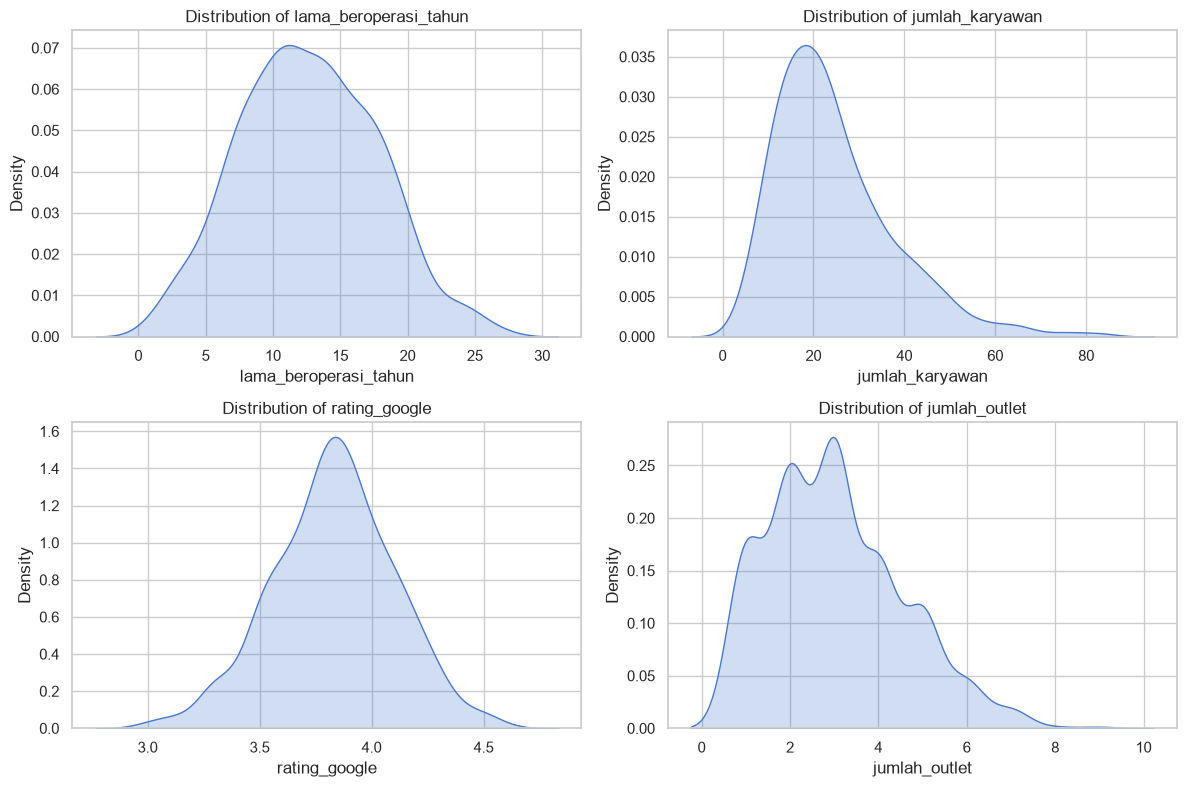

In [30]:
# make density subplots visualization
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# convert array 2d into 1d for looping purposes
ax = ax.flatten()

for i, col in enumerate(profile_clean.select_dtypes(include='number').columns):  
    sns.kdeplot(
        data=profile_clean,
        x=col,
        fill=True,
        ax=ax[i]
    )
    ax[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

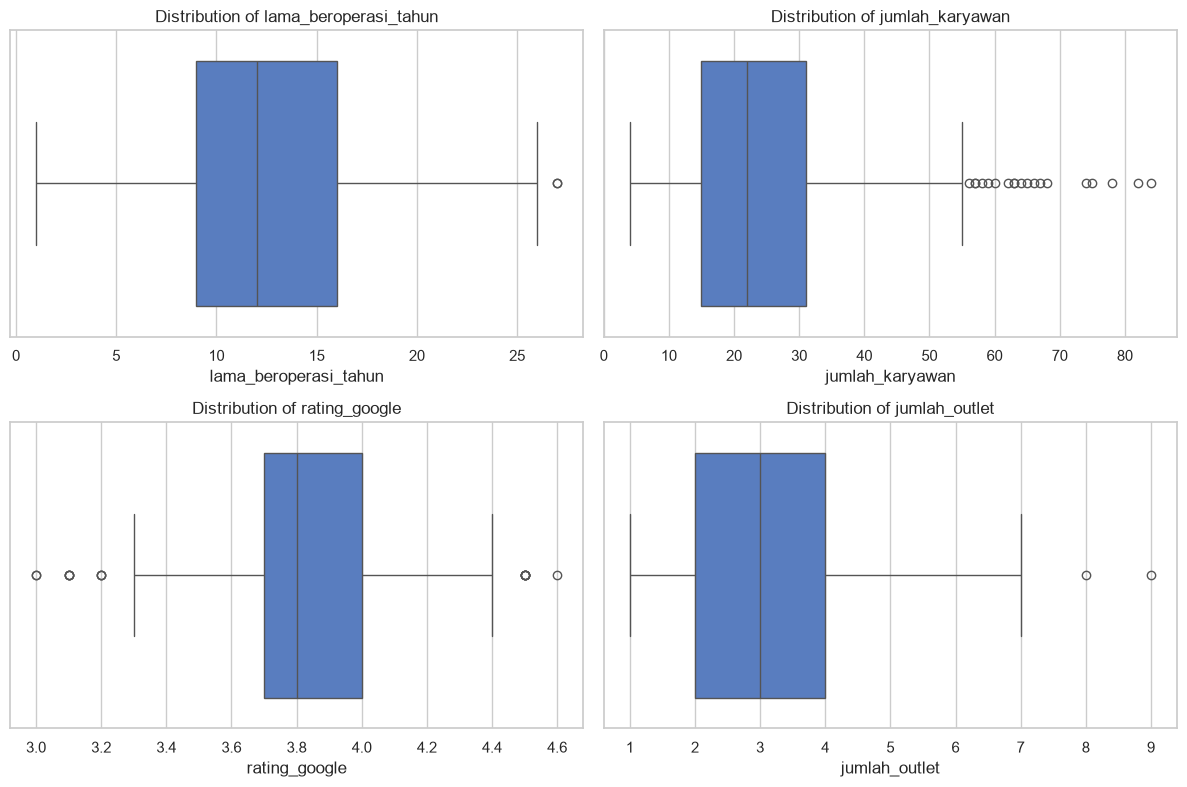

In [31]:
# make boxplot subplots visualization
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# convert array 2d into 1d for looping purposes
ax = ax.flatten()

for i, col in enumerate(profile_clean.select_dtypes(include='number').columns):  
    sns.boxplot(
        data=profile_clean,
        x=col,
        fill=True,
        ax=ax[i]
    )
    ax[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [32]:
# fill missing value with median
for col in ['lama_beroperasi_tahun', 'jumlah_karyawan', 'jumlah_outlet']:
    median_val = profile_clean[col].median()
    null_count = profile_clean[col].isna().sum()
    profile_clean[col] = profile_clean[col].fillna(median_val)
    print(f"Fill {col} NULL ({null_count}) with median ({median_val})")

# let null value on rating_google, make new features has_rating containing binary values 
profile_clean['has_rating'] = profile_clean['rating_google'].notna().astype(int)
profile_clean['rating_google'] = profile_clean['rating_google'].fillna(0)  # 0 = no rating

# has_website dan has_social_media — encode ke binary
profile_clean['has_website'] = (profile_clean['has_website'] == 'Ya').astype(int)
profile_clean['has_social_media'] = (profile_clean['has_social_media'] == 'Ya').astype(int)

print(f"\nProfile clean shape: {profile_clean.shape}")
print(f"Missing values: {profile_clean.isnull().sum().sum()}")

Fill lama_beroperasi_tahun NULL (63) with median (12.0)
Fill jumlah_karyawan NULL (77) with median (22.0)
Fill jumlah_outlet NULL (37) with median (3.0)

Profile clean shape: (708, 8)
Missing values: 0


# **4. Exploratory Data Analysis**

Section ini memberikan gambaran deskriptif atas data yang sudah dibersihkan: komposisi merchant, skala usaha, omzet, profil operasional, serta pola umum transaksi. Analisis customer affinity dan pembentukan graph dilakukan terpisah pada notebook 02.

## **4.1 Merchant Population Overview**

In [33]:
# Jumlah merchant menurut skala usaha dan status acquiring BNI.
merchant_scale_summary = (
    merchants_clean.groupby(['skala_usaha', 'is_bni_acquiring'], observed=False)
    .agg(jumlah_merchant=('merchant_id', 'nunique'))
    .reset_index()
)
merchant_scale_summary['skala_usaha'] = pd.Categorical(
    merchant_scale_summary['skala_usaha'], categories=SCALE_ORDER, ordered=True
)
merchant_scale_summary = merchant_scale_summary.sort_values(
    ['skala_usaha', 'is_bni_acquiring']
)
display(merchant_scale_summary)

,skala_usaha,is_bni_acquiring,jumlah_merchant
6,UMI,Tidak,61
7,UMI,Ya,208
2,UKE,Tidak,103
3,UKE,Ya,162
4,UME,Tidak,69
5,UME,Ya,74
0,UBE,Tidak,13
1,UBE,Ya,18


In [34]:
# Ringkasan target akuisisi secara deskriptif.
target_merchants = merchants_clean[
    merchants_clean['is_bni_acquiring'].eq('Tidak')
].copy()

target_scale_summary = (
    target_merchants['skala_usaha']
    .value_counts()
    .reindex(SCALE_ORDER, fill_value=0)
    .rename('jumlah_target')
    .to_frame()
)
target_scale_summary['persentase'] = (
    100 * target_scale_summary['jumlah_target'] / target_scale_summary['jumlah_target'].sum()
)

print(f'Total merchant       : {len(merchants_clean):,}')
print(f'Merchant BNI         : {merchants_clean["is_bni_acquiring"].eq("Ya").sum():,}')
print(f'Target non-BNI       : {len(target_merchants):,}')
print(f'Target UKE/UME       : {target_merchants["skala_usaha"].isin(["UKE", "UME"]).sum():,}')
display(target_scale_summary.round({'persentase': 1}))

Total merchant       : 708
Merchant BNI         : 462
Target non-BNI       : 246
Target UKE/UME       : 172


,jumlah_target,persentase
skala_usaha,,
UMI,61,24.8
UKE,103,41.9
UME,69,28.0
UBE,13,5.3


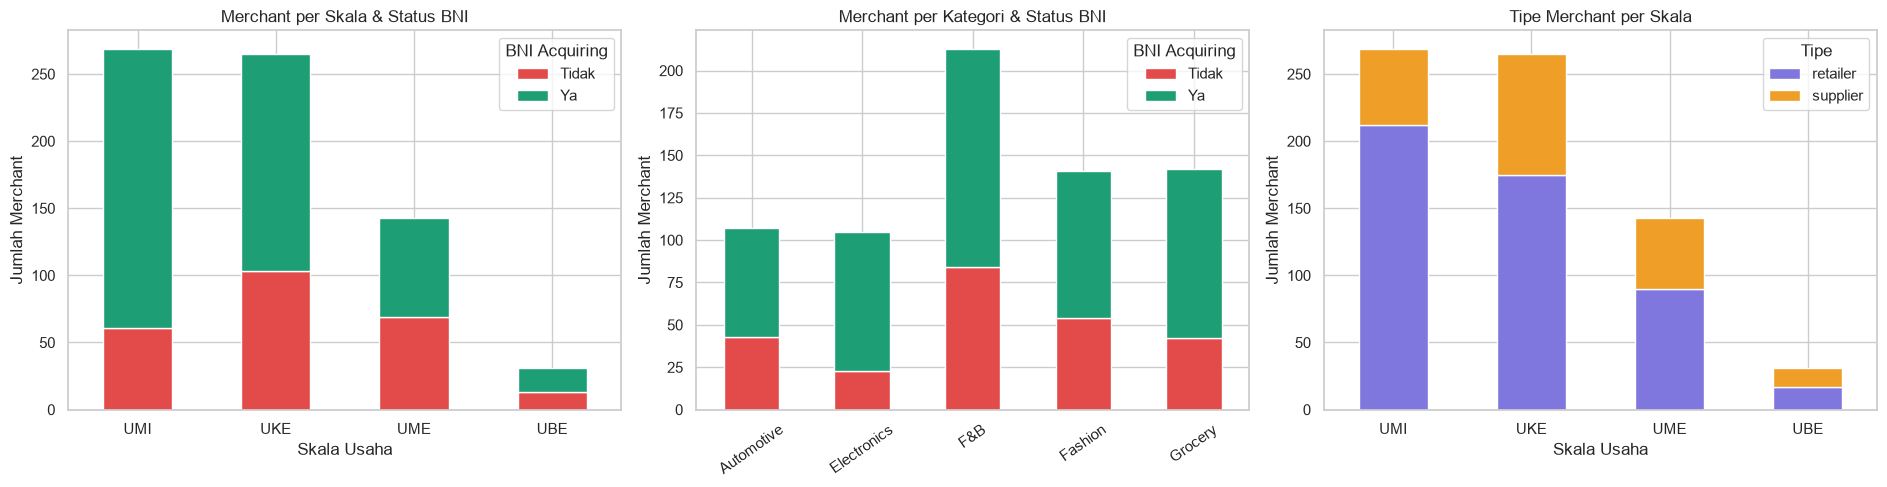

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
scale_colors = {'UMI': '#7F77DD', 'UKE': '#1D9E75', 'UME': '#EF9F27', 'UBE': '#E24B4A'}

# Plot 1: merchant per skala dan status acquiring.
scale_status = (
    pd.crosstab(merchants_clean['skala_usaha'], merchants_clean['is_bni_acquiring'])
    .reindex(SCALE_ORDER, fill_value=0)
)
scale_status.plot(kind='bar', stacked=True, ax=axes[0], color=['#E24B4A', '#1D9E75'])
axes[0].set_title('Merchant per Skala & Status BNI')
axes[0].set_xlabel('Skala Usaha')
axes[0].set_ylabel('Jumlah Merchant')
axes[0].legend(title='BNI Acquiring')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: merchant per kategori dan status acquiring.
category_status = pd.crosstab(
    merchants_clean['kategori'], merchants_clean['is_bni_acquiring']
)
category_status.plot(kind='bar', stacked=True, ax=axes[1], color=['#E24B4A', '#1D9E75'])
axes[1].set_title('Merchant per Kategori & Status BNI')
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Merchant')
axes[1].legend(title='BNI Acquiring')
axes[1].tick_params(axis='x', rotation=35)

# Plot 3: retailer vs supplier per skala.
scale_type = (
    pd.crosstab(merchants_clean['skala_usaha'], merchants_clean['tipe'])
    .reindex(SCALE_ORDER, fill_value=0)
)
scale_type.plot(kind='bar', stacked=True, ax=axes[2], color=['#7F77DD', '#EF9F27'])
axes[2].set_title('Tipe Merchant per Skala')
axes[2].set_xlabel('Skala Usaha')
axes[2].set_ylabel('Jumlah Merchant')
axes[2].legend(title='Tipe')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/01_merchant_population.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.2 Turnover & Merchant Profile Overview**

,count,min,median,mean,max
skala_usaha,,,,,
UMI,269,"Rp 17,530,932","Rp 44,619,151","Rp 51,917,392","Rp 146,033,143"
UKE,265,"Rp 193,126,836","Rp 484,059,382","Rp 537,864,879","Rp 1,197,327,101"
UME,143,"Rp 1,365,007,500","Rp 2,581,870,275","Rp 2,643,115,022","Rp 4,100,000,000"
UBE,31,"Rp 5,305,077,368","Rp 7,036,963,476","Rp 7,059,675,330","Rp 9,000,000,000"


,count,mean,std,min,25%,50%,75%,max
lama_beroperasi_tahun,708.0,12.57,4.86,1.0,9.00,12.0,16.0,27.0
jumlah_karyawan,708.0,24.22,12.46,4.0,16.00,22.0,29.0,84.0
jumlah_outlet,708.0,3.01,1.47,1.0,2.00,3.0,4.0,9.0
rating_google,708.0,2.87,1.68,0.0,2.25,3.7,3.9,4.6


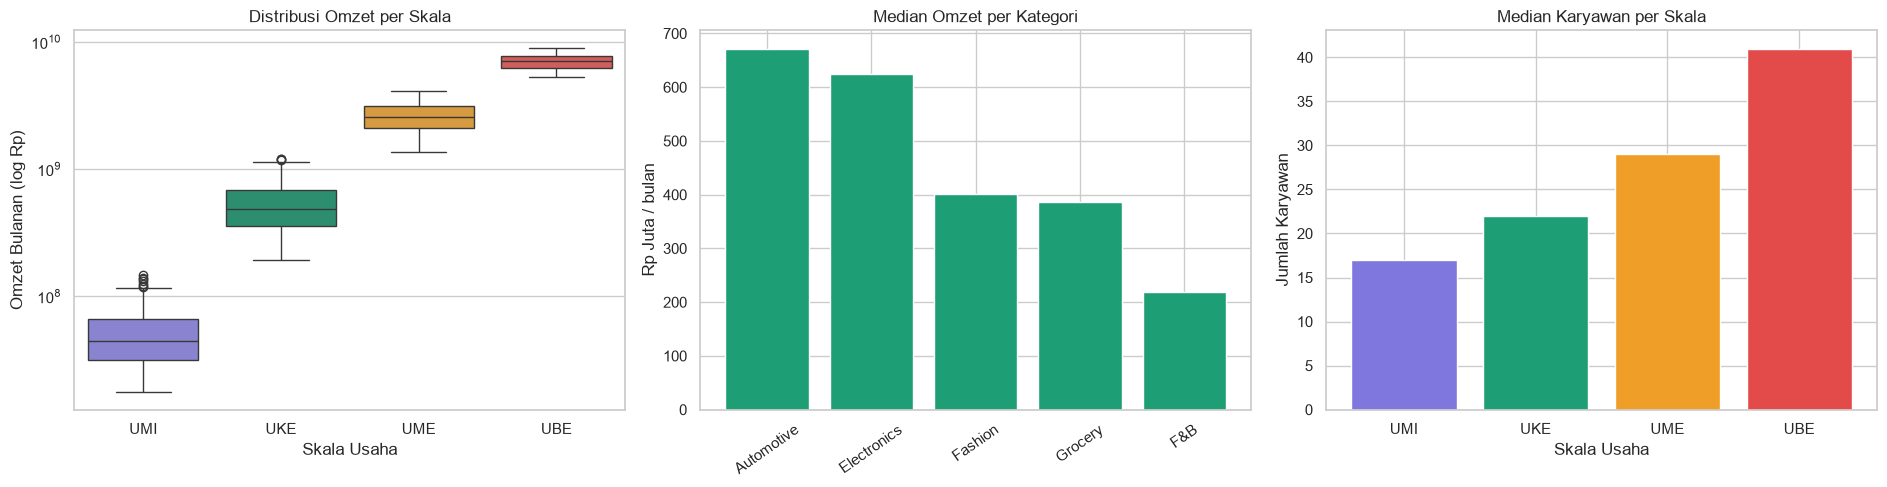

In [36]:
# Canonical enriched table: merchant attributes + operational profile.
merchants_enriched = merchants_clean.merge(
    profile_clean, on='merchant_id', how='left', validate='one_to_one'
)

turnover_by_scale = (
    merchants_enriched.groupby('skala_usaha', observed=False)['avg_omzet_bulanan']
    .agg(['count', 'min', 'median', 'mean', 'max'])
    .reindex(SCALE_ORDER)
)
display(turnover_by_scale.style.format({
    'min': 'Rp {:,.0f}',
    'median': 'Rp {:,.0f}',
    'mean': 'Rp {:,.0f}',
    'max': 'Rp {:,.0f}',
}))

profile_summary = merchants_enriched[[
    'lama_beroperasi_tahun', 'jumlah_karyawan', 'jumlah_outlet', 'rating_google'
]].describe().T
display(profile_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Plot 1: turnover range must remain distinct across business scales.
sns.boxplot(
    data=merchants_enriched, x='skala_usaha', y='avg_omzet_bulanan',
    order=SCALE_ORDER, palette=scale_colors, ax=axes[0]
)
axes[0].set_yscale('log')
axes[0].set_title('Distribusi Omzet per Skala')
axes[0].set_xlabel('Skala Usaha')
axes[0].set_ylabel('Omzet Bulanan (log Rp)')

# Plot 2: median turnover by merchant category.
median_turnover_category = (
    merchants_enriched.groupby('kategori')['avg_omzet_bulanan'].median()
    .sort_values(ascending=False) / 1e6
)
axes[1].bar(median_turnover_category.index, median_turnover_category.values, color='#1D9E75')
axes[1].set_title('Median Omzet per Kategori')
axes[1].set_xlabel('')
axes[1].set_ylabel('Rp Juta / bulan')
axes[1].tick_params(axis='x', rotation=35)

# Plot 3: employee profile by business scale.
employee_by_scale = (
    merchants_enriched.groupby('skala_usaha', observed=False)['jumlah_karyawan']
    .median().reindex(SCALE_ORDER)
)
axes[2].bar(
    employee_by_scale.index, employee_by_scale.values,
    color=[scale_colors[s] for s in SCALE_ORDER]
)
axes[2].set_title('Median Karyawan per Skala')
axes[2].set_xlabel('Skala Usaha')
axes[2].set_ylabel('Jumlah Karyawan')

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/02_turnover_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.3 Transaction Composition Overview**

,jumlah_transaksi,total_nilai,median_nilai,unique_source,unique_target
trx_type,,,,,
C2M,49066,"Rp 641,835,127,651","Rp 9,037,789",2000,708
M2M,16610,"Rp 420,575,464,152","Rp 15,551,041",708,708


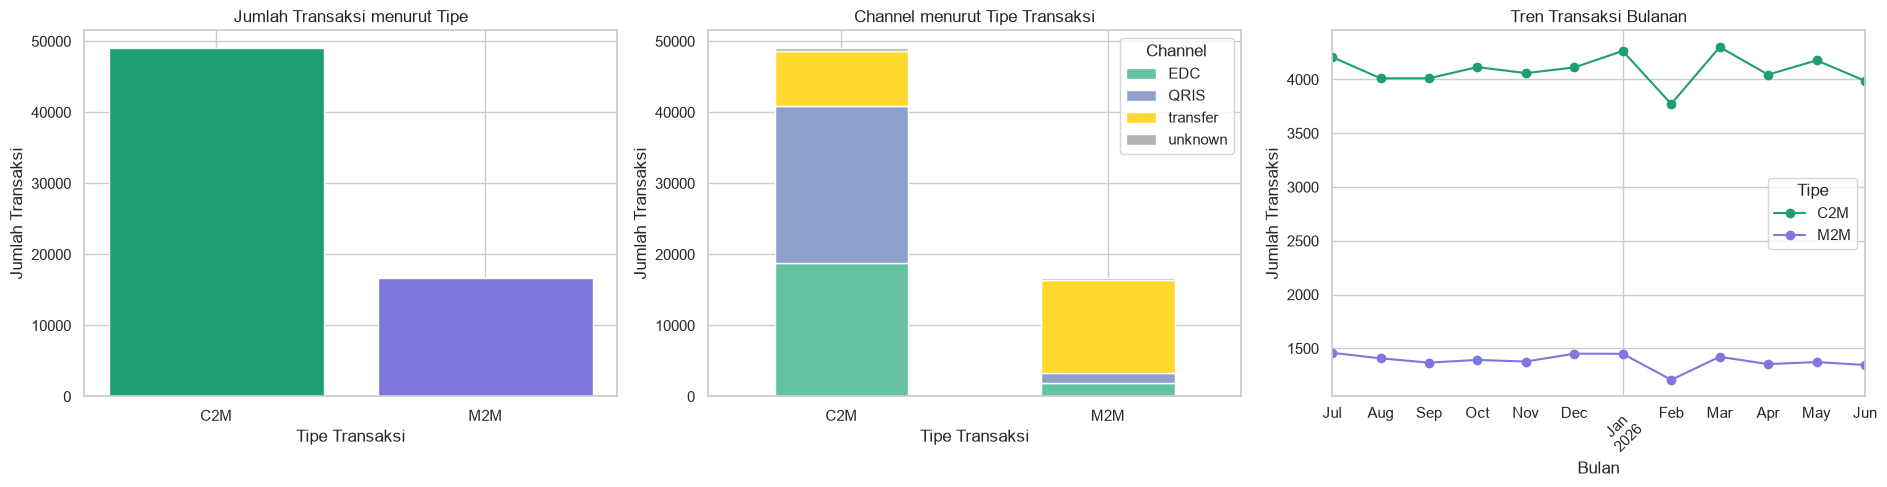

In [37]:
transaction_summary = (
    trx_clean.groupby('trx_type')
    .agg(
        jumlah_transaksi=('trx_id', 'count'),
        total_nilai=('amount', 'sum'),
        median_nilai=('amount', 'median'),
        unique_source=('source_id', 'nunique'),
        unique_target=('target_id', 'nunique'),
    )
)
display(transaction_summary.style.format({
    'total_nilai': 'Rp {:,.0f}',
    'median_nilai': 'Rp {:,.0f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Plot 1: overall C2M vs M2M composition.
trx_type_count = trx_clean['trx_type'].value_counts()
axes[0].bar(trx_type_count.index, trx_type_count.values, color=['#1D9E75', '#7F77DD'])
axes[0].set_title('Jumlah Transaksi menurut Tipe')
axes[0].set_xlabel('Tipe Transaksi')
axes[0].set_ylabel('Jumlah Transaksi')

# Plot 2: channel composition for each transaction type.
channel_by_type = pd.crosstab(trx_clean['trx_type'], trx_clean['channel'])
channel_by_type.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Channel menurut Tipe Transaksi')
axes[1].set_xlabel('Tipe Transaksi')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].legend(title='Channel')
axes[1].tick_params(axis='x', rotation=0)

# Plot 3: monthly transaction trend, still purely descriptive.
monthly_type = trx_clean.groupby(['month', 'trx_type']).size().unstack(fill_value=0)
monthly_type.plot(ax=axes[2], marker='o', color=['#1D9E75', '#7F77DD'])
axes[2].set_title('Tren Transaksi Bulanan')
axes[2].set_xlabel('Bulan')
axes[2].set_ylabel('Jumlah Transaksi')
axes[2].legend(title='Tipe')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/03_transaction_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.4 Transaction Amount Overview**

,trx_type,channel,count,median,mean,max
0,C2M,EDC,18829,"Rp 12,048,224","Rp 16,431,842","Rp 200,000,000"
1,C2M,QRIS,22112,"Rp 5,244,303","Rp 7,942,364","Rp 158,593,752"
2,C2M,transfer,7652,"Rp 14,859,624","Rp 19,666,856","Rp 200,000,000"
3,C2M,unknown,473,"Rp 9,942,252","Rp 13,377,656","Rp 159,072,789"
4,M2M,EDC,1941,"Rp 15,035,881","Rp 24,958,701","Rp 75,000,000"
5,M2M,QRIS,1295,"Rp 15,596,429","Rp 25,491,641","Rp 75,000,000"
6,M2M,transfer,13201,"Rp 15,600,575","Rp 25,346,715","Rp 75,000,000"
7,M2M,unknown,173,"Rp 15,590,440","Rp 26,109,591","Rp 75,000,000"


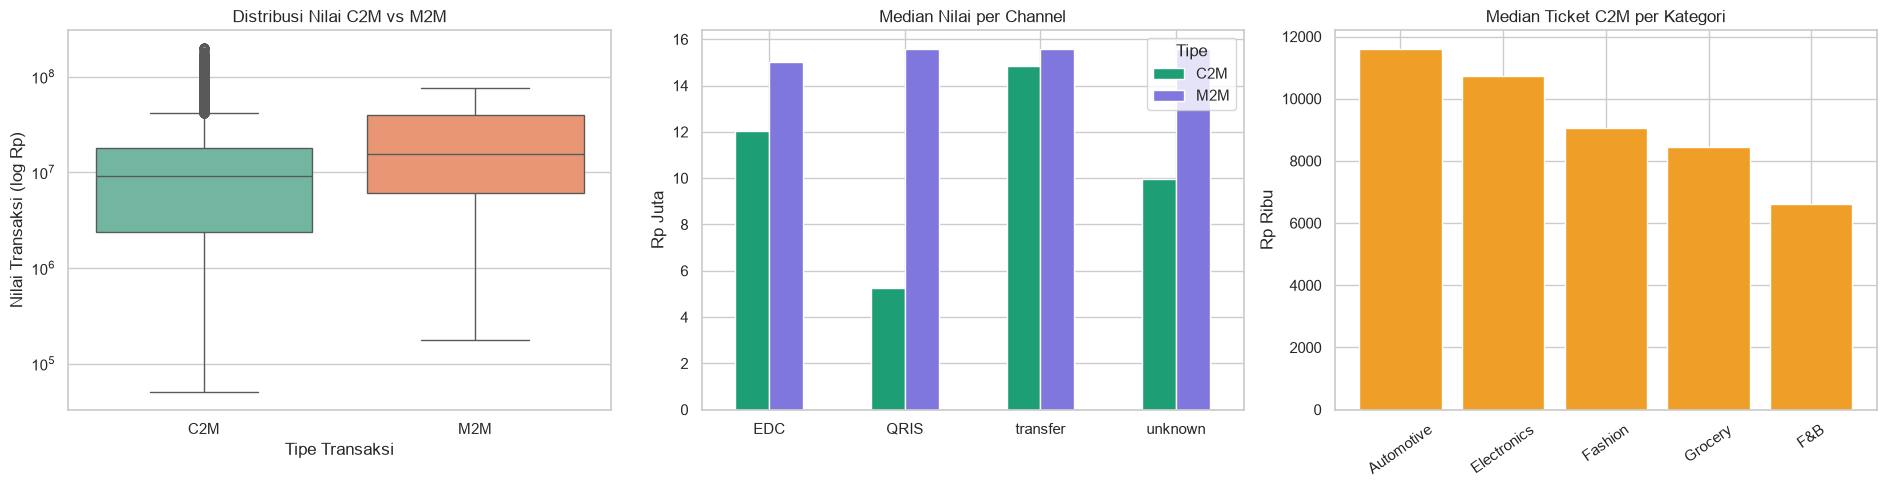

In [38]:
amount_by_type_channel = (
    trx_clean.groupby(['trx_type', 'channel'])['amount']
    .agg(['count', 'median', 'mean', 'max'])
    .reset_index()
)
display(amount_by_type_channel.style.format({
    'median': 'Rp {:,.0f}',
    'mean': 'Rp {:,.0f}',
    'max': 'Rp {:,.0f}',
}))

# Merchant category is added only to describe C2M ticket size; no graph is built here.
trx_c2m_desc = trx_clean[trx_clean['trx_type'].eq('C2M')].merge(
    merchants_clean[['merchant_id', 'kategori', 'skala_usaha']],
    left_on='target_id', right_on='merchant_id', how='inner', validate='many_to_one'
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Plot 1: amount distribution by transaction type.
sns.boxplot(data=trx_clean, x='trx_type', y='amount', ax=axes[0], palette='Set2')
axes[0].set_yscale('log')
axes[0].set_title('Distribusi Nilai C2M vs M2M')
axes[0].set_xlabel('Tipe Transaksi')
axes[0].set_ylabel('Nilai Transaksi (log Rp)')

# Plot 2: median amount by channel and transaction type.
median_channel = trx_clean.pivot_table(
    index='channel', columns='trx_type', values='amount', aggfunc='median'
) / 1e6
median_channel.plot(kind='bar', ax=axes[1], color=['#1D9E75', '#7F77DD'])
axes[1].set_title('Median Nilai per Channel')
axes[1].set_xlabel('')
axes[1].set_ylabel('Rp Juta')
axes[1].legend(title='Tipe')
axes[1].tick_params(axis='x', rotation=0)

# Plot 3: C2M median ticket by merchant category.
c2m_ticket_category = (
    trx_c2m_desc.groupby('kategori')['amount'].median().sort_values(ascending=False) / 1e3
)
axes[2].bar(c2m_ticket_category.index, c2m_ticket_category.values, color='#EF9F27')
axes[2].set_title('Median Ticket C2M per Kategori')
axes[2].set_xlabel('')
axes[2].set_ylabel('Rp Ribu')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/04_transaction_amount.png', dpi=150, bbox_inches='tight')
plt.show()

## **4.5 Existing BNI Product Overview**

produk_bni,QRIS,QRIS + EDC
skala_usaha,,
UMI,155,53
UKE,53,109
UME,5,69
UBE,0,18


Existing merchant BNI : 462
Distribusi produk:
produk_bni
QRIS + EDC    249
QRIS          213
Name: count, dtype: int64


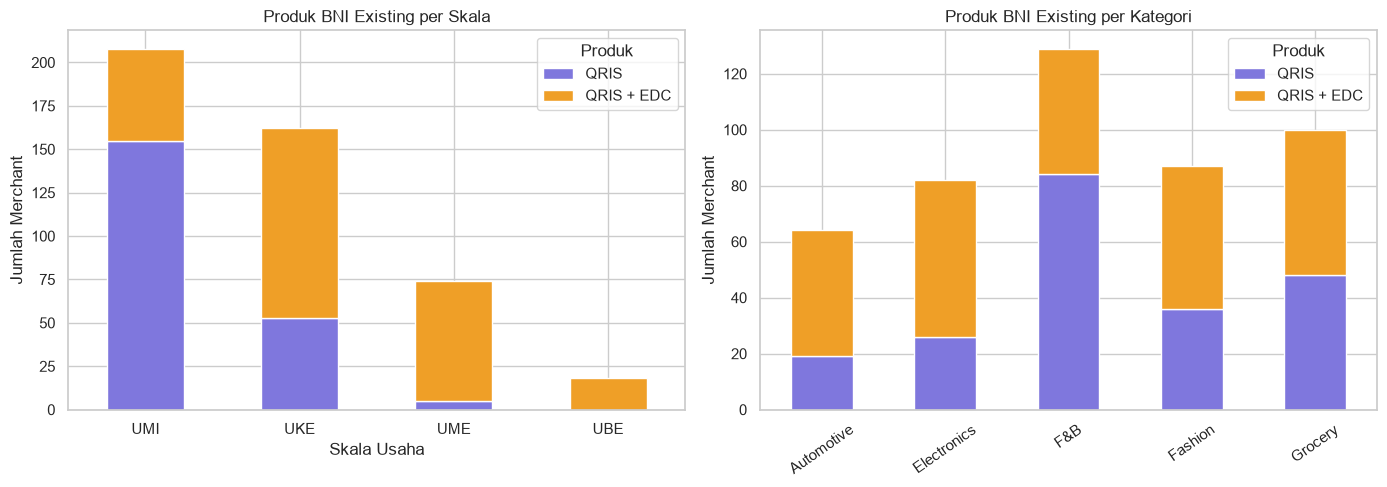

In [39]:
existing_bni = merchants_clean[
    merchants_clean['is_bni_acquiring'].eq('Ya')
].copy()

product_summary = (
    existing_bni.groupby(['skala_usaha', 'produk_bni'], observed=False)
    .size().unstack(fill_value=0)
    .reindex(SCALE_ORDER, fill_value=0)
)
display(product_summary)

print(f'Existing merchant BNI : {len(existing_bni):,}')
print('Distribusi produk:')
print(existing_bni['produk_bni'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

product_summary.plot(
    kind='bar', stacked=True, ax=axes[0], color=['#7F77DD', '#EF9F27']
)
axes[0].set_title('Produk BNI Existing per Skala')
axes[0].set_xlabel('Skala Usaha')
axes[0].set_ylabel('Jumlah Merchant')
axes[0].legend(title='Produk')
axes[0].tick_params(axis='x', rotation=0)

product_category = pd.crosstab(existing_bni['kategori'], existing_bni['produk_bni'])
product_category.plot(
    kind='bar', stacked=True, ax=axes[1], color=['#7F77DD', '#EF9F27']
)
axes[1].set_title('Produk BNI Existing per Kategori')
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Merchant')
axes[1].legend(title='Produk')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/plots/05_existing_product.png', dpi=150, bbox_inches='tight')
plt.show()

# **5. Save Processed Data**

## 5. Merchant MDR & Fee-Based Income Profile

Economic profile dihitung **langsung dari transaksi C2M sukses yang teramati**, bukan dari `avg_omzet_bulanan`.

- Gross MDR = Σ(`amount` × MDR rate)
- Net fee-based income (FBI) = 85% × Gross MDR
- QRIS: UMI ≤ Rp500 ribu = 0%; UMI > Rp500 ribu = 0,3%; UKE/UME/UBE = 0,7%.
- EDC debit = 0,15% (seluruh debit synthetic diasumsikan debit BNI/on-us); credit card = 2%.
- Bank transfer tidak dihitung sebagai acquiring MDR.

Notebook 01 hanya menghasilkan **building block economics** per merchant. Product cost, contribution, dan expected loss baru dihitung **setelah product recommendation** di notebook 05/dashboard.


In [40]:
# Transaction-based acquiring economics (building block, belum memakai hasil model produk)
NET_FBI_SHARE = 0.85
MDR_QRIS_UMI_HIGH = 0.003
MDR_QRIS_REGULAR = 0.007
MDR_EDC_DEBIT = 0.0015
MDR_EDC_CREDIT = 0.02

trx_econ = trx_clean[trx_clean['trx_type'].eq('C2M')].copy()
trx_econ = trx_econ.merge(
    merchants_clean[['merchant_id', 'skala_usaha']],
    left_on='target_id', right_on='merchant_id', how='left', validate='many_to_one'
)

qris_rate = np.where(
    trx_econ['payment_type'].eq('QRIS'),
    np.where(
        trx_econ['skala_usaha'].eq('UMI'),
        np.where(trx_econ['amount'].le(500_000), 0.0, MDR_QRIS_UMI_HIGH),
        MDR_QRIS_REGULAR,
    ),
    0.0,
)
edc_rate = np.select(
    [trx_econ['payment_type'].eq('debit'), trx_econ['payment_type'].eq('credit_card')],
    [MDR_EDC_DEBIT, MDR_EDC_CREDIT],
    default=0.0,
)

trx_econ['gross_qris_mdr'] = trx_econ['amount'] * qris_rate
trx_econ['gross_edc_mdr'] = trx_econ['amount'] * edc_rate
trx_econ['qris_amount'] = np.where(trx_econ['payment_type'].eq('QRIS'), trx_econ['amount'], 0.0)
trx_econ['edc_amount'] = np.where(trx_econ['payment_type'].isin(['debit','credit_card']), trx_econ['amount'], 0.0)

period_start = trx_econ['timestamp_dt'].min().to_period('M')
period_end = trx_econ['timestamp_dt'].max().to_period('M')
OBSERVATION_MONTHS = (period_end.year - period_start.year) * 12 + (period_end.month - period_start.month) + 1

agg = trx_econ.groupby('target_id').agg(
    observed_qris_amount=('qris_amount','sum'),
    observed_edc_amount=('edc_amount','sum'),
    gross_qris_mdr_period=('gross_qris_mdr','sum'),
    gross_edc_mdr_period=('gross_edc_mdr','sum'),
).reset_index().rename(columns={'target_id':'merchant_id'})

merchant_mdr_profile = merchants_clean[['merchant_id']].merge(agg, on='merchant_id', how='left')
num_cols = [c for c in merchant_mdr_profile.columns if c != 'merchant_id']
merchant_mdr_profile[num_cols] = merchant_mdr_profile[num_cols].fillna(0.0)
merchant_mdr_profile['observation_months'] = OBSERVATION_MONTHS
merchant_mdr_profile['monthly_gross_qris_mdr'] = merchant_mdr_profile['gross_qris_mdr_period'] / OBSERVATION_MONTHS
merchant_mdr_profile['monthly_gross_edc_mdr'] = merchant_mdr_profile['gross_edc_mdr_period'] / OBSERVATION_MONTHS
merchant_mdr_profile['monthly_net_qris_fbi'] = merchant_mdr_profile['monthly_gross_qris_mdr'] * NET_FBI_SHARE
merchant_mdr_profile['monthly_net_edc_fbi'] = merchant_mdr_profile['monthly_gross_edc_mdr'] * NET_FBI_SHARE
merchant_mdr_profile['monthly_net_total_fbi'] = merchant_mdr_profile['monthly_net_qris_fbi'] + merchant_mdr_profile['monthly_net_edc_fbi']

print(f'Observation window: {period_start} s.d. {period_end} ({OBSERVATION_MONTHS} bulan)')
display(merchant_mdr_profile[['monthly_gross_qris_mdr','monthly_gross_edc_mdr','monthly_net_total_fbi']].describe().T)


Observation window: 2025-07 s.d. 2026-06 (12 bulan)


,count,mean,std,min,25%,50%,75%,max
monthly_gross_qris_mdr,708.0,142821.913811,126789.493371,0.000000,1524.965613,163699.126830,238508.011318,6.250273e+05
monthly_gross_edc_mdr,708.0,288463.595736,399242.729112,54.223404,4527.762748,178939.325436,387041.414728,3.059161e+06
monthly_net_total_fbi,708.0,366592.683115,420311.428186,688.477681,5180.328180,307291.923682,540035.688084,3.088729e+06


In [41]:
merchants_clean.to_csv(f'{PROJECT_ROOT}/data/processed/merchants_clean.csv', index=False)
trx_clean.to_csv(f'{PROJECT_ROOT}/data/processed/transactions_clean.csv', index=False)
profile_clean.to_csv(f'{PROJECT_ROOT}/data/processed/profiles_clean.csv', index=False)
merchants_enriched.to_csv(f'{PROJECT_ROOT}/data/processed/merchants_enriched.csv', index=False)
merchant_mdr_profile.to_csv(f'{PROJECT_ROOT}/data/processed/merchant_mdr_profile.csv', index=False)

print("Saving processed data. . .")
print(f"merchants_clean.csv:      {len(merchants_clean)} rows")
print(f"transactions_clean.csv:   {len(trx_clean)} rows")
print(f"profiles_clean.csv:       {len(profile_clean)} rows")
print(f"merchants_enriched.csv:   {len(merchants_enriched)} rows")
print(f"merchant_mdr_profile.csv: {len(merchant_mdr_profile)} rows")

Saving processed data. . .
merchants_clean.csv:      708 rows
transactions_clean.csv:   65676 rows
profiles_clean.csv:       708 rows
merchants_enriched.csv:   708 rows
merchant_mdr_profile.csv: 708 rows


In [42]:
# Verifikasi output notebook 01
print("=== VERIFIKASI OUTPUT NOTEBOOK 01 ===")
print(f"merchants_clean    : {len(merchants_clean)} merchant")
print(f"  BNI              : {(merchants_clean['is_bni_acquiring']=='Ya').sum()}")
print(f"  Bukan BNI        : {(merchants_clean['is_bni_acquiring']=='Tidak').sum()}")
print(f"  Target UKE/UME   : {((merchants_clean['is_bni_acquiring']=='Tidak') & merchants_clean['skala_usaha'].isin(['UKE','UME'])).sum()}")
print(f"  Produk QRIS      : {(merchants_clean['produk_bni']=='QRIS').sum()}")
print(f"  Produk QRIS+EDC  : {(merchants_clean['produk_bni']=='QRIS + EDC').sum()}")
print(f"  Produk NULL      : {merchants_clean['produk_bni'].isna().sum()}")
print(f"transactions_clean : {len(trx_clean)} transaksi")
print(f"  C2M              : {(trx_clean['trx_type']=='C2M').sum()}")
print(f"  M2M              : {(trx_clean['trx_type']=='M2M').sum()}")
print(f"  Payment types    : {sorted(trx_clean['payment_type'].dropna().unique())}")

# Leakage guard: product label belongs only to merchant data and was not an input
# to synthetic transaction generation.
assert 'produk_bni' not in trx_raw.columns
print("\n✓ Skala/omzet valid; transaksi tidak membawa target produk; siap untuk notebook 02")

=== VERIFIKASI OUTPUT NOTEBOOK 01 ===
merchants_clean    : 708 merchant
  BNI              : 462
  Bukan BNI        : 246
  Target UKE/UME   : 172
  Produk QRIS      : 213
  Produk QRIS+EDC  : 249
  Produk NULL      : 246
transactions_clean : 65676 transaksi
  C2M              : 49066
  M2M              : 16610
  Payment types    : ['QRIS', 'bank_transfer', 'credit_card', 'debit', 'unknown']

✓ Skala/omzet valid; transaksi tidak membawa target produk; siap untuk notebook 02
